# 03 — Classical ML Classification

This notebook evaluates classical machine-learning classifiers using the leakage-safe feature set produced in `02_EDA_and_PCA_codex.ipynb`.

**Input**
- Elastic Net-selected descriptor matrix from `data/model_input_elasticnet.joblib`
- 30 selected RDKit descriptors
- Stratified 70/30 train/test split from the previous notebook

**Goal**
- Establish a small-data baseline before any deep-learning model
- Compare simple linear and kernel-based classifiers
- Report test-set performance with accuracy, balanced accuracy, macro F1, and a confusion matrix

## 3.1 Import Libraries

In [231]:
import os
from collections import OrderedDict

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC

FIGURES_DIR = "figures"
DATA_DIR = "data"
ARTIFACT_PATH = os.path.join(DATA_DIR, "model_input_elasticnet.joblib")
RESULTS_PATH = os.path.join(DATA_DIR, "classical_ml_results.csv")
CONFUSION_MATRIX_PATH = os.path.join(FIGURES_DIR, "confusion_matrix_classical_ml.png")

RANDOM_STATE = 42
CV_FOLDS = 5

CLASS_NAMES = ["Capsaicinoid", "Vanilloid_Gingerol", "Spice_Alkaloid"]

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## 3.2 Load Elastic Net Feature-Selection Artifact

The previous notebook already performed the leakage-safe train/test split, Elastic Net feature selection, and train-only scaling. Here, we load those saved arrays directly instead of refitting preprocessing.

In [232]:
if not os.path.exists(ARTIFACT_PATH):
    raise FileNotFoundError(
        f"{ARTIFACT_PATH} not found. "
        "Run 02_EDA_and_PCA_codex.ipynb first to generate it."
    )

artifact = joblib.load(ARTIFACT_PATH)

X_train = artifact["X_train_scaled"]
X_test = artifact["X_test_scaled"]
y_train = artifact["y_train"]
y_test = artifact["y_test"]
selected_features = artifact["selected_features"]

train_counts = {name: int((y_train == i).sum()) for i, name in enumerate(CLASS_NAMES)}
test_counts = {name: int((y_test == i).sum()) for i, name in enumerate(CLASS_NAMES)}

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Selected features: {len(selected_features)}")
print(f"Class counts (train): {train_counts}")
print(f"Class counts (test):  {test_counts}")
print()
print("First 10 selected features:")
print(selected_features[:10])

Train shape: (69, 30)
Test shape:  (30, 30)
Selected features: 30
Class counts (train): {'Capsaicinoid': 23, 'Vanilloid_Gingerol': 23, 'Spice_Alkaloid': 23}
Class counts (test):  {'Capsaicinoid': 10, 'Vanilloid_Gingerol': 10, 'Spice_Alkaloid': 10}

First 10 selected features:
['MinAbsEStateIndex', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'BCUT2D_LOGPLOW', 'Chi0n', 'Chi0v', 'Chi1n', 'Chi1v']


## 3.3 Model Candidates

Because this is a small dataset, the first modeling pass uses compact classical classifiers rather than a neural network. Logistic Regression and Linear SVM test whether the Elastic Net-selected feature space is mostly linearly separable. RBF SVM adds one non-linear baseline. The SVM `C` values were chosen manually as lightweight settings for this mini project, not through an aggressive grid search.


In [233]:
models = OrderedDict({
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Linear SVM": SVC(
        kernel="linear",
        C=0.2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RBF SVM": SVC(
        kernel="rbf",
        C=3.0,
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
})

print(f"Models: {list(models.keys())}")

Models: ['Logistic Regression', 'Linear SVM', 'RBF SVM']


## 3.4 Cross-Validation on the Training Set

Cross-validation is performed only on the training set. The held-out test set is reserved for the final model comparison below.


In [235]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro"
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
    )
    cv_rows.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std()
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["cv_macro_f1_mean", "cv_balanced_accuracy_mean", "cv_macro_f1_std"],
    ascending=[False, False, True],
    kind="stable",
).reset_index(drop=True)

cv_results.round(3)

,model,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std
0,RBF SVM,0.929,0.064,0.927,0.067,0.928,0.065
1,Linear SVM,0.914,0.083,0.913,0.085,0.916,0.083
2,Logistic Regression,0.900,0.057,0.900,0.059,0.901,0.058


## 3.5 Test-Set Evaluation Helper

Each model is evaluated on the same held-out test set. I use one helper function only to avoid repeating plotting code; the three model results are still shown in separate cells below.

In [236]:
def evaluate_test_model(model_name, model, figure_path):
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)

    metrics = {
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
    }

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", colorbar=False, values_format="d")
    plt.title(f"{model_name} Confusion Matrix (test set accuracy = {metrics['test_accuracy']:.3f})")
    plt.tight_layout()
    plt.savefig(figure_path, bbox_inches="tight")
    plt.show()

    print(f"{model_name} test metrics")
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.3f}")
        else:
            print(f"{key}: {value}")
    print(f"Saved: {figure_path}")

    return metrics, y_pred


## 3.6 Logistic Regression

This is the simplest linear baseline. It is useful because it shows how far the Elastic Net-selected descriptor space can go with a plain linear decision boundary.

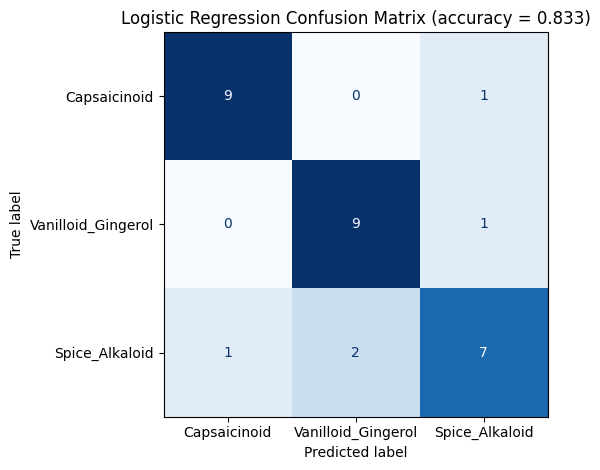

Logistic Regression test metrics
model: Logistic Regression
test_accuracy: 0.833
test_balanced_accuracy: 0.833
test_macro_f1: 0.831
Saved: figures/confusion_matrix_logistic_regression.png


In [237]:
logistic_metrics, logistic_pred = evaluate_test_model(
    "Logistic Regression",
    models["Logistic Regression"],
    os.path.join(FIGURES_DIR, "confusion_matrix_logistic_regression.png")
)


## 3.7 Linear SVM

Linear SVM is another linear classifier, but it optimizes a margin-based objective instead of logistic probability. If it matches Logistic Regression closely, that suggests the selected feature space is already mostly linearly separable.

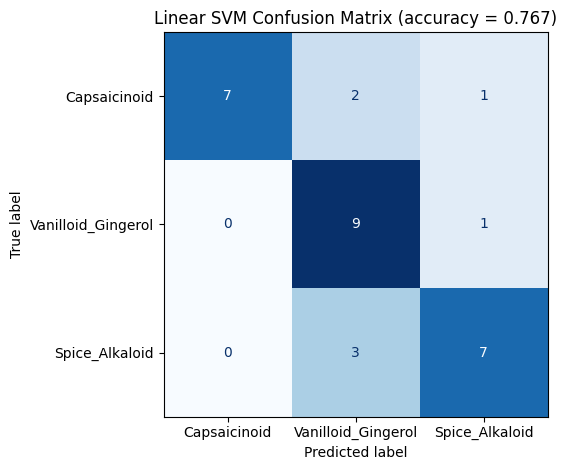

Linear SVM test metrics
model: Linear SVM
test_accuracy: 0.767
test_balanced_accuracy: 0.767
test_macro_f1: 0.770
Saved: figures/confusion_matrix_linear_svm.png


In [238]:
linear_svm_metrics, linear_svm_pred = evaluate_test_model(
    "Linear SVM",
    models["Linear SVM"],
    os.path.join(FIGURES_DIR, "confusion_matrix_linear_svm.png")
)


## 3.8 RBF SVM

RBF SVM adds a non-linear boundary. This is the main check for whether a curved decision boundary improves classification beyond the two linear baselines.

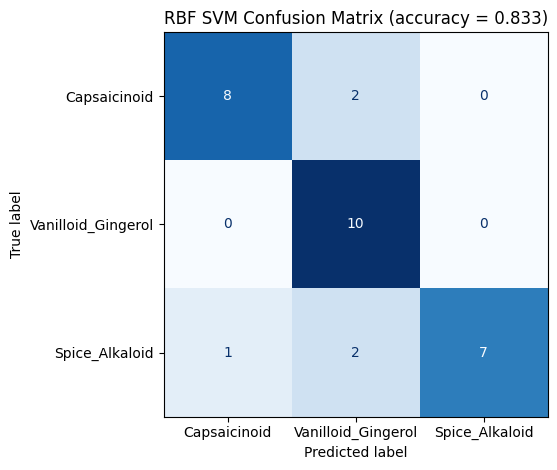

RBF SVM test metrics
model: RBF SVM
test_accuracy: 0.833
test_balanced_accuracy: 0.833
test_macro_f1: 0.833
Saved: figures/confusion_matrix_rbf_svm.png


In [239]:
rbf_svm_metrics, rbf_svm_pred = evaluate_test_model(
    "RBF SVM",
    models["RBF SVM"],
    os.path.join(FIGURES_DIR, "confusion_matrix_rbf_svm.png")
)


## 3.9 Compare Test Metrics

The table below compares the three models on the test set. Accuracy gives the overall hit rate, balanced accuracy checks class-wise balance, and macro F1 gives each chemical family equal weight.

In [240]:
test_results = pd.DataFrame([
    logistic_metrics,
    linear_svm_metrics,
    rbf_svm_metrics,
]).sort_values(
    ["test_macro_f1", "test_balanced_accuracy", "test_accuracy"],
    ascending=[False, False, False],
    kind="stable",
).reset_index(drop=True)

test_results.round(3)


,model,test_accuracy,test_balanced_accuracy,test_macro_f1
0,RBF SVM,0.833,0.833,0.833
1,Logistic Regression,0.833,0.833,0.831
2,Linear SVM,0.767,0.767,0.770


## 3.10 Classification Reports

The reports below show precision, recall, and F1 score for each class. This is useful because the two linear models perform similarly, while the RBF SVM improves the final test metrics and changes the error pattern.

In [241]:
for model_name, pred in [
    ("Logistic Regression", logistic_pred),
    ("Linear SVM", linear_svm_pred),
    ("RBF SVM", rbf_svm_pred),
]:
    print(f"\n{model_name}")
    print(classification_report(
        y_test,
        pred,
        target_names=CLASS_NAMES,
        zero_division=0
    ))



Logistic Regression
                    precision    recall  f1-score   support

      Capsaicinoid       0.90      0.90      0.90        10
Vanilloid_Gingerol       0.82      0.90      0.86        10
    Spice_Alkaloid       0.78      0.70      0.74        10

          accuracy                           0.83        30
         macro avg       0.83      0.83      0.83        30
      weighted avg       0.83      0.83      0.83        30


Linear SVM
                    precision    recall  f1-score   support

      Capsaicinoid       1.00      0.70      0.82        10
Vanilloid_Gingerol       0.64      0.90      0.75        10
    Spice_Alkaloid       0.78      0.70      0.74        10

          accuracy                           0.77        30
         macro avg       0.81      0.77      0.77        30
      weighted avg       0.81      0.77      0.77        30


RBF SVM
                    precision    recall  f1-score   support

      Capsaicinoid       0.89      0.80      0.84  

## 3.11 Save Results

The saved CSV combines cross-validation metrics and held-out test metrics for all three models.

In [242]:
results_df = cv_results.merge(test_results, on="model", how="left")
results_df = results_df.sort_values(
    ["test_macro_f1", "test_balanced_accuracy", "test_accuracy"],
    ascending=[False, False, False],
    kind="stable",
).reset_index(drop=True)

results_df.to_csv(RESULTS_PATH, index=False)
print(f"Saved: {RESULTS_PATH}")
results_df.round(3)


Saved: data/classical_ml_results.csv


,model,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_balanced_accuracy,test_macro_f1
0,RBF SVM,0.929,0.064,0.927,0.067,0.928,0.065,0.833,0.833,0.833
1,Logistic Regression,0.900,0.057,0.900,0.059,0.901,0.058,0.833,0.833,0.831
2,Linear SVM,0.914,0.083,0.913,0.085,0.916,0.083,0.767,0.767,0.770


## 3.12 Final Interpretation

PCA alone was not used as the main modeling step because it is unsupervised: it keeps directions with high variance, not necessarily directions that separate the three chemical families. In Notebook 02, Elastic Net was used as a penalized, label-aware feature-selection step to reduce the original RDKit descriptor set before modeling. The PCA plots in Notebook 02 are visual diagnostics only; the actual model prediction and evaluation are performed here in Notebook 03.

The linear models provide an important baseline. Logistic Regression and Linear SVM reached the same test accuracy and made very similar errors, suggesting that most of the Elastic Net-selected descriptor space can be explained with a mostly linear decision boundary. `RBF SVM` performed best in the final comparison table, which suggests that a small amount of non-linear flexibility helps capture the remaining edge cases. In the test confusion matrix, the RBF model cleanly recovered the Vanilloid/Gingerol class, while Spice Alkaloids remained the most difficult group.

In a separate molecular-descriptor-based classification group project, adding Morgan fingerprints and Tanimoto similarity features improved accuracy and related evaluation metrics. For this mini project, I intentionally kept the modeling scope narrower: additional chemistry-specific feature engineering, aggressive grid search, and ANN testing were left out because the dataset is small and the main goal is to show how supervised feature selection changes the quality and interpretability of a molecular classification workflow.
